In [25]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [26]:
df = pd.read_csv('data/store.csv')
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1115 entries, 0 to 1114
Data columns (total 10 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Store                      1115 non-null   int64  
 1   StoreType                  1115 non-null   object 
 2   Assortment                 1115 non-null   object 
 3   CompetitionDistance        1112 non-null   float64
 4   CompetitionOpenSinceMonth  761 non-null    float64
 5   CompetitionOpenSinceYear   761 non-null    float64
 6   Promo2                     1115 non-null   int64  
 7   Promo2SinceWeek            571 non-null    float64
 8   Promo2SinceYear            571 non-null    float64
 9   PromoInterval              571 non-null    object 
dtypes: float64(5), int64(2), object(3)
memory usage: 87.2+ KB


In [27]:
int_cols = ['CompetitionOpenSinceMonth', 'CompetitionOpenSinceYear', 'Promo2SinceWeek', 'Promo2SinceYear']
df[int_cols] = df[int_cols].fillna(-1).astype(int)

In [28]:
df.describe()

,Store,CompetitionDistance,CompetitionOpenSinceMonth,CompetitionOpenSinceYear,Promo2,Promo2SinceWeek,Promo2SinceYear
count,1115.00000,1112.000000,1115.000000,1115.000000,1115.000000,1115.000000,1115.00000
mean,558.00000,5404.901079,4.613453,1370.621525,0.512108,11.595516,1029.75157
std,322.01708,7663.174720,4.659540,935.933356,0.500078,15.925223,1006.53886
min,1.00000,20.000000,-1.000000,-1.000000,0.000000,-1.000000,-1.00000
25%,279.50000,717.500000,-1.000000,-1.000000,0.000000,-1.000000,-1.00000
50%,558.00000,2325.000000,4.000000,2006.000000,1.000000,1.000000,2009.00000
75%,836.50000,6882.500000,9.000000,2011.000000,1.000000,22.000000,2012.00000
max,1115.00000,75860.000000,12.000000,2015.000000,1.000000,50.000000,2015.00000


In [29]:
df.head()

,Store,StoreType,Assortment,CompetitionDistance,CompetitionOpenSinceMonth,CompetitionOpenSinceYear,Promo2,Promo2SinceWeek,Promo2SinceYear,PromoInterval
0,1,c,a,1270.0,9,2008,0,-1,-1,NaN
1,2,a,a,570.0,11,2007,1,13,2010,"Jan,Apr,Jul,Oct"
2,3,a,a,14130.0,12,2006,1,14,2011,"Jan,Apr,Jul,Oct"
3,4,c,c,620.0,9,2009,0,-1,-1,NaN
4,5,a,a,29910.0,4,2015,0,-1,-1,NaN


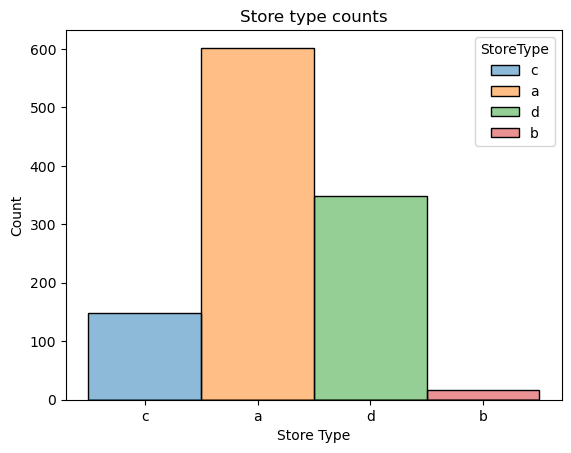

In [32]:
sns.histplot(data=df, x='StoreType', hue = 'StoreType' ,kde=False)
plt.title('Store type counts')
plt.xlabel('Store Type')
plt.ylabel('Count')
plt.show()

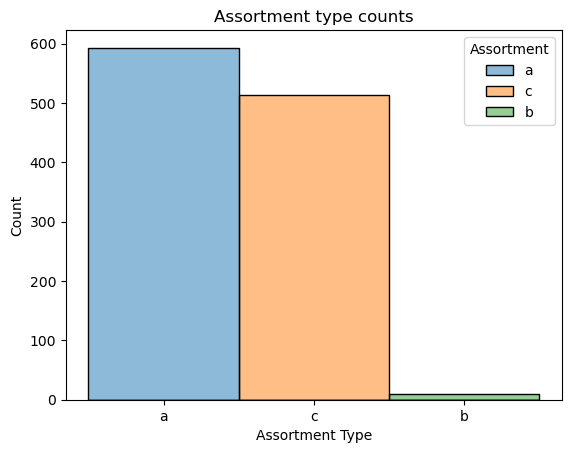

In [33]:
sns.histplot(data=df, x='Assortment', hue = 'Assortment' ,kde=False)
plt.title('Assortment type counts')
plt.xlabel('Assortment Type')
plt.ylabel('Count')
plt.show()

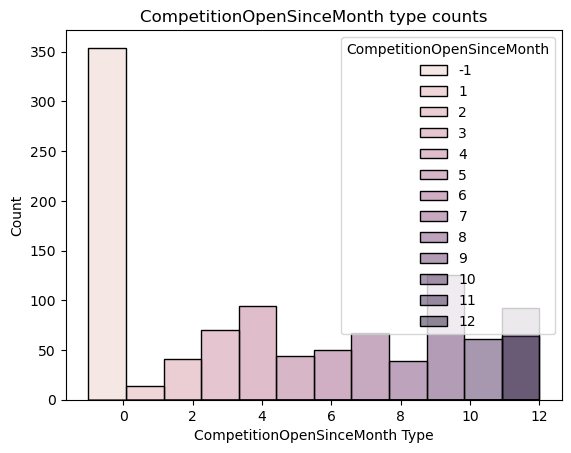

In [34]:
sns.histplot(data=df, x='CompetitionOpenSinceMonth', hue = 'CompetitionOpenSinceMonth' ,kde=False)
plt.title('CompetitionOpenSinceMonth type counts')
plt.xlabel('CompetitionOpenSinceMonth Type')
plt.ylabel('Count')
plt.show()

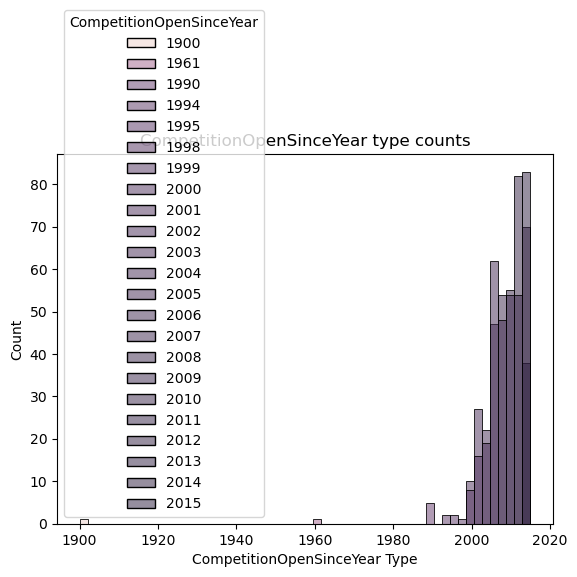

In [37]:
sns.histplot(data=df[df['CompetitionOpenSinceYear' ]!= -1], x='CompetitionOpenSinceYear', hue = 'CompetitionOpenSinceYear' ,kde=False)
plt.title('CompetitionOpenSinceYear type counts')
plt.xlabel('CompetitionOpenSinceYear Type')
plt.ylabel('Count')
plt.show()

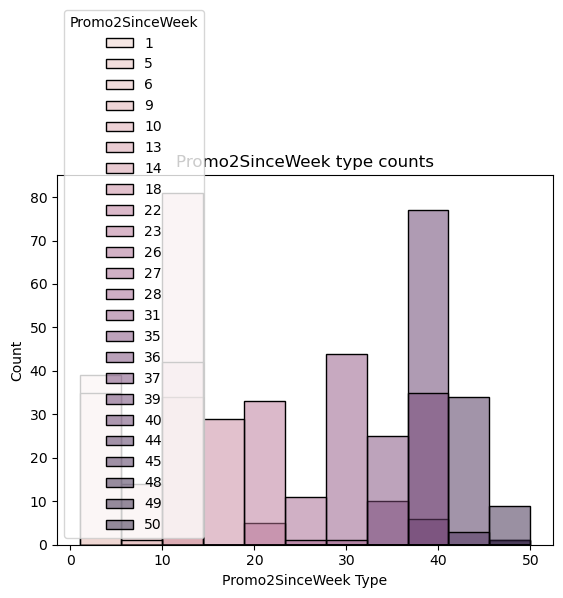

In [38]:
sns.histplot(data=df[df['Promo2SinceWeek' ]!= -1], x='Promo2SinceWeek', hue = 'Promo2SinceWeek' ,kde=False)
plt.title('Promo2SinceWeek type counts')
plt.xlabel('Promo2SinceWeek Type')
plt.ylabel('Count')
plt.show()

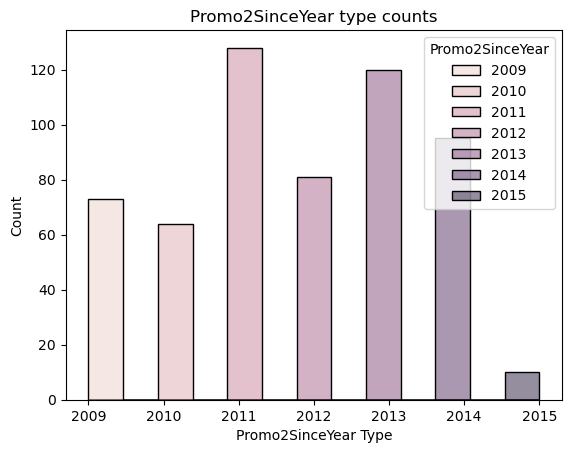

In [39]:
sns.histplot(data=df[df['Promo2SinceYear' ]!= -1], x='Promo2SinceYear', hue = 'Promo2SinceYear' ,kde=False)
plt.title('Promo2SinceYear type counts')
plt.xlabel('Promo2SinceYear Type')
plt.ylabel('Count')
plt.show()

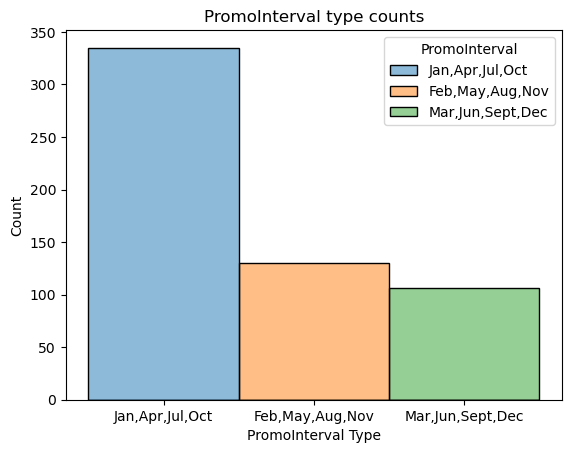

In [40]:
sns.histplot(data=df, x='PromoInterval', hue = 'PromoInterval' ,kde=False)
plt.title('PromoInterval type counts')
plt.xlabel('PromoInterval Type')
plt.ylabel('Count')
plt.show()

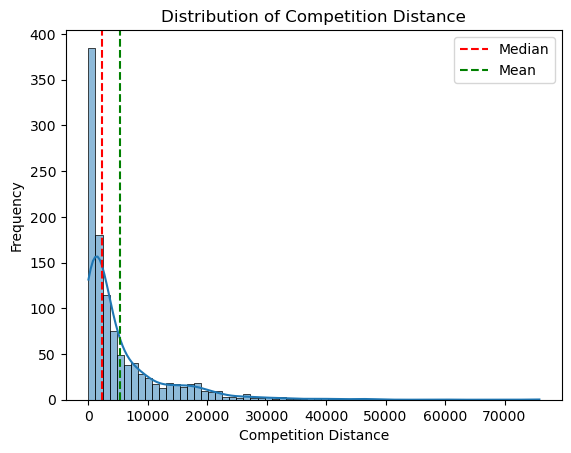

In [41]:
med = df['CompetitionDistance'].median()
avg = df['CompetitionDistance'].mean()

sns.histplot(data=df, x='CompetitionDistance', kde=True)
plt.axvline(med, color='r', linestyle='--', label='Median')
plt.axvline(avg, color='g', linestyle='--', label='Mean')
plt.title('Distribution of Competition Distance')
plt.xlabel('Competition Distance')
plt.ylabel('Frequency')
plt.legend()
plt.show()

In [42]:
# Since we have a left skewed distribution of competion distance,
# let's transform it to log and square root and see which yield similarity
# to a normal/gaussian distribution
min_dist_val = df['CompetitionDistance'].min()
df['Log_CompetitionDistance'] = np.log(df['CompetitionDistance']  + 1)
df['Sqrt_CompetitionDistance'] = np.sqrt(df['CompetitionDistance'])

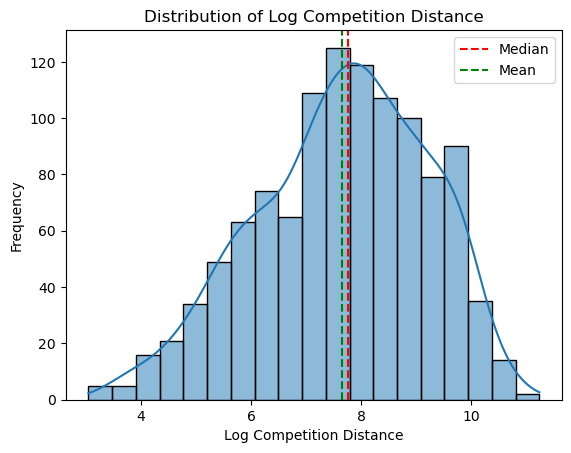

In [43]:
med = df['Log_CompetitionDistance'].median()
avg = df['Log_CompetitionDistance'].mean()

sns.histplot(data=df, x='Log_CompetitionDistance', kde=True)
plt.axvline(med, color='r', linestyle='--', label='Median')
plt.axvline(avg, color='g', linestyle='--', label='Mean')
plt.title('Distribution of Log Competition Distance')
plt.xlabel('Log Competition Distance')
plt.ylabel('Frequency')
plt.legend()
plt.show()

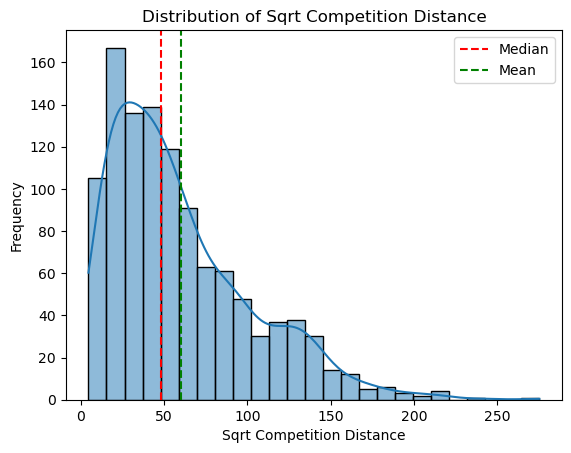

In [44]:
med = df['Sqrt_CompetitionDistance'].median()
avg = df['Sqrt_CompetitionDistance'].mean()

sns.histplot(data=df, x='Sqrt_CompetitionDistance', kde=True)
plt.axvline(med, color='r', linestyle='--', label='Median')
plt.axvline(avg, color='g', linestyle='--', label='Mean')
plt.title('Distribution of Sqrt Competition Distance')
plt.xlabel('Sqrt Competition Distance')
plt.ylabel('Frequency')
plt.legend()
plt.show()

# We can clearly see that the log transformaation resembles a more normal distribution than sqrt transformation.